# Imports

In [2]:
import urllib
from sklearn.datasets import load_sample_image
from sklearn.feature_extraction import image
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Creating the Index for the Key Frames Embedding


In [11]:
from opensearchpy import OpenSearch
host = 'api.novasearch.org'
port = 443

user = 'user13' 
password = 'rumoao+20' 
index_name = user # We can only have an index with the same name has our user name.

# Create the client with SSL/TLS enabled, but hostname verification disabled.
client = OpenSearch(
    hosts = [{'host': host, 'port': port}],
    http_compress = True, # enables gzip compression for request bodies
    http_auth = (user, password),
    use_ssl = True,
    url_prefix = 'opensearch_v2',
    verify_certs = False,
    ssl_assert_hostname = False,
    ssl_show_warn = False
)

# Create the index with knn_vector mapping
index_body = {
    "settings":{
      "index":{
         "number_of_replicas":0,
         "number_of_shards":4,
         "refresh_interval":"1s",
         "knn":"true"
      }
   },
    "mappings": {
        "properties": {
            "video_id": {"type": "keyword"},
            "frame_file": {"type": "keyword"},
            "label": {"type": "keyword"},
            "start_time": {"type": "float"},
            "end_time": {"type": "float"},
            "captions": {"type": "text"},
            "frame_embedding": {
                "type": "knn_vector",
                "dimension": 512,
                "method": {
                    "name": "hnsw",
                    "space_type": "cosinesimil",
                    "engine": "nmslib"
                }
            },
            "label_embedding": {
                "type": "knn_vector",
                "dimension": 512,
                "method": {
                    "name": "hnsw",
                    "space_type": "cosinesimil",
                    "engine": "nmslib"
                }
            },
            "caption_embeddings": {
                "type": "knn_vector",
                "dimension": 512,
                "method": {
                    "name": "hnsw",
                    "space_type": "cosinesimil",
                    "engine": "nmslib"
                }
            },
            "video_path": {"type": "keyword"},
            "duration": {"type": "float"}
        }
    }
}

if not client.indices.exists(index=index_name):
    client.indices.create(index=index_name, body=index_body)
    print(f"Índice '{index_name}' criado.")
else:
    print(f"Índice '{index_name}' já existe.")
    
#if client.indices.exists(index=index_name): response = client.indices.delete(index=index_name)



Índice 'user13' criado.


# Extracting Key Frames


In [4]:
import os
import yt_dlp

def download_video(youtube_url, output_dir="videos"):
    os.makedirs(output_dir, exist_ok=True)
    
    # Set download options
    ydl_opts = {
        "format": "bestvideo+bestaudio/best",
        "outtmpl": os.path.join(output_dir, "%(title)s.%(ext)s"),
        "noplaylist": True,
        "quiet": False,  # Show download progress
    }

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(youtube_url, download=True)
            video_file = os.path.join(output_dir, f"{info['title']}.{info['ext']}")
            #print(f"Downloaded: {video_file}")
            return video_file

    except yt_dlp.utils.DownloadError as e:
        print(f"Failed to download {youtube_url}: {e}")
        return None
    except Exception as e:
        print(f"Unexpected error with {youtube_url}: {e}")
        return None


In [6]:
import cv2
import os

def extract_keyframes(video_url, output_dir, interval=2):
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Open the video file
    video_path = download_video(video_url, output_dir= "videos")
    
    if video_path is None:
        # Video has most likely been deleted or privated
        return False
    
    cap = cv2.VideoCapture(video_path)
    frame_rate = cap.get(cv2.CAP_PROP_FPS)  # Get frames per second
    frame_interval = int(frame_rate * interval)  # Convert to frame interval

    frame_count = 0
    saved_count = 0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Save frame every 'interval' seconds
        if frame_count % frame_interval == 0:
            frame_file = os.path.join(output_dir, f"frame_{saved_count:04d}.jpg")
            cv2.imwrite(frame_file, frame)
            #print(f"Saved: {frame_file}")
            saved_count += 1
        
        frame_count += 1
        
    #print(f"Extracted {saved_count} keyframes from '{video_path}' to '{output_dir}'")
    cap.release()
    return True




# Computing CLIP Embeddings of Key Frames


In [8]:
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import os

# Computes CLIP embeddings for all images in a directory and returns them in a dictionary with filenames as keys
def compute_clip_embeddings(image_dir, device='cuda' if torch.cuda.is_available() else 'cpu'):
    # Load CLIP model and processor
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    embeddings = {}

    for filename in sorted(os.listdir(image_dir)):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            image_path = os.path.join(image_dir, filename)
            image = Image.open(image_path).convert("RGB")

            inputs = processor(images=image, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model.get_image_features(**inputs)
                normalized = outputs / outputs.norm(p=2, dim=-1, keepdim=True)
                embeddings[filename] = normalized.cpu().tolist()

    return embeddings

#image_dir = "keyframes/o1WPnnvs00I"
#embeddings = compute_clip_embeddings(image_dir)

# Importing the Dataset and Indexing its Data
New version of the cell from project-main.ipynb. Indexes by keyframe and associates their captions

In [9]:
# This function is used to get the captions that are within the timeframe of the video.
def get_caption_from_timeframe(captions_starts:[], captions_ends:[], en_captions: [], f_start_time: float, f_end_time:float):
    #matching_starts = []
    #matching_ends = []
    matching_captions = [""]
    
    for i, caption in enumerate(en_captions):
        print(f"Caption {caption} starts at {captions_starts[i]} and ends at {captions_ends[i]}")
        print(f"Frame starts at {f_start_time} and ends at {f_end_time}")
        if captions_starts[i] <= f_start_time and captions_ends[i] >= f_end_time:
            #matching_starts.append(captions_starts[i])
            #matching_ends.append(captions_ends[i])
            matching_captions.append(caption)
            print(f"Caption {caption} matches the timeframe from {f_start_time} to {f_end_time}")
    
    return matching_captions

In [ ]:
# Run this script to index the videos and their metadata into OpenSearch

import os
import json
from datasets import load_dataset

# Load the dataset, trust_remote_code=True is needed to load the dataset from the remote repository.
# This is where we get our captions from.
dataset = load_dataset('dataset-download.py', trust_remote_code=True) 

# Load the CLIP Model and Processor for embedding the image and text fields
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

index_name = "user13"
index_number_id = 0  # Index number to use as document ID (0, 1, 2, ...)

# Load captions and video metadata
with open("top10.json", "r") as data_file:
    video_metadata = json.load(data_file)

# Directory containing the extracted keyframes
keyframes_dir = "keyframes"

# Iterate over each video in the dataset and store their metadata
videos_info = {}
for split in ['train', 'test', 'validation']:
    for video in dataset[split]:
        video['video_id'] = video['video_id'].replace("v_", "")
        
        # Iterate through the documents in doc_list
        videos_info[video['video_id']] = {
            "video_id": video['video_id'],
            "url": video['video_path'],
            "duration": video['duration'],
            "captions_starts": video['captions_starts'],
            "captions_ends": video['captions_ends'],
            "captions": video['en_captions'],
        }
        
        #print(f"Video ID: {video['video_id']}")

# Iterate over each video
for video_id, video_info in video_metadata.items():
    # Download the video and extract frames every 2 seconds
    if extract_keyframes(video_url= video_info['url'], output_dir=f"{keyframes_dir}/{video_id}", interval= 2) == False:
        print(f"Failed to extract keyframes for video {video_id}. Skipping...")
        continue
    
    # Get the stored frames of the video
    # keyframes/{video_id}/frame_0000.jpg
    video_keyframes_dir = os.path.join(keyframes_dir, video_id)
    frame_files = sorted(os.listdir(video_keyframes_dir))
    
    # Compute CLIP image/frame embeddings
    # frame_embeddings = <frame_file>: [<embedding>]
    frame_embeddings = compute_clip_embeddings(image_dir = f"{keyframes_dir}/{video_id}")

    for i, frame_file in enumerate(frame_files):
        # Skip if the file is not a valid image
        # This can happen if the video has been privated and therefore no download happenned
        if frame_file not in frame_embeddings:
            print(f"Warning: Frame '{frame_file}' not found in embeddings. Skipping...")
            continue
        
        # Calculate the timestamp range for this frame
        frame_duration = 2.0
        start_time = i * frame_duration
        end_time = start_time + frame_duration
        
        # Find captions that overlap with this frame's time range
        matching_video_info = videos_info[video_id]
        matching_captions = get_caption_from_timeframe(matching_video_info["captions_starts"], matching_video_info["captions_ends"], matching_video_info["captions"], start_time, end_time)
        
        # Find labels that overlap with this frame's time range
        label = ""
        for annotation in video_info["annotations"]:
            if (annotation["segment"][0] >= start_time and annotation["segment"][1] <= end_time):
                label = annotation["label"]
        
        # Generate caption embeddings
        inputs = processor(text=matching_captions, return_tensors="pt", padding=True).to(device)
        caption_embeddings = model.get_text_features(**inputs)
        caption_embeddings = caption_embeddings / caption_embeddings.norm(dim=-1, keepdim=True)
        caption_embeddings = caption_embeddings.detach().cpu().tolist()
        
        # Generate label embeddings
        inputs = processor(text=label, return_tensors="pt", padding=True).to(device)
        label_embeddings = model.get_text_features(**inputs)
        label_embeddings = label_embeddings / label_embeddings.norm(dim=-1, keepdim=True)
        label_embeddings = label_embeddings.detach().cpu().tolist()

        # Check if caption_embeddings is not empty to avoid IndexError
        if not caption_embeddings or not caption_embeddings[0]:
            print(f"Warning: No caption embeddings for frame '{frame_file}' in video '{video_id}'. Skipping...")
            continue

        # Create the OpenSearch document
        doc = {
            "video_id": video_id,
            "frame_file": frame_file,
            "start_time": start_time,
            "end_time": end_time,
            "captions": matching_captions,
            "label": label,
            "label_embeddings": label_embeddings[0],
            "frame_embedding": frame_embeddings[frame_file][0],
            "caption_embeddings": caption_embeddings[0],
            "video_path": video_info["url"],
            "duration": video_info["duration"]
        }
        
        # Check if this is really needed
        if doc['duration'] is None:
            print(f"Warning: Duration for video '{video_id}' is None. Skipping...")
            continue
        
        # Index the document
        try:
            response = client.index(index=index_name, id=index_number_id, body=doc)
            print(f"Indexed document {index_number_id}: {response}")
            index_number_id += 1
        except Exception as e:
            print(f"Error indexing document {index_number_id}: {e}")


# Refresh the index so the docs are searchable
client.indices.refresh(index = 'user13')


[youtube] Extracting URL: https://www.youtube.com/watch?v=o1WPnnvs00I
[youtube] o1WPnnvs00I: Downloading webpage
[youtube] o1WPnnvs00I: Downloading tv client config
[youtube] o1WPnnvs00I: Downloading tv player API JSON
[youtube] o1WPnnvs00I: Downloading ios player API JSON
[youtube] o1WPnnvs00I: Downloading m3u8 information
[info] o1WPnnvs00I: Downloading 1 format(s): 135+251


ERROR: You have requested merging of multiple formats but ffmpeg is not installed. Aborting due to --abort-on-error


Failed to download https://www.youtube.com/watch?v=o1WPnnvs00I: ERROR: You have requested merging of multiple formats but ffmpeg is not installed. Aborting due to --abort-on-error
Failed to extract keyframes for video o1WPnnvs00I. Skipping...
[youtube] Extracting URL: https://www.youtube.com/watch?v=oGwn4NUeoy8
[youtube] oGwn4NUeoy8: Downloading webpage
[youtube] oGwn4NUeoy8: Downloading tv client config
[youtube] oGwn4NUeoy8: Downloading tv player API JSON
[youtube] oGwn4NUeoy8: Downloading ios player API JSON


[youtube] oGwn4NUeoy8: Downloading ios player API JSON


[youtube] oGwn4NUeoy8: Downloading ios player API JSON


...

ERROR: [youtube] PJ72Yl0B1rY: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies


Failed to download https://www.youtube.com/watch?v=PJ72Yl0B1rY: ERROR: [youtube] PJ72Yl0B1rY: Private video. Sign in if you've been granted access to this video. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies
Failed to extract keyframes for video PJ72Yl0B1rY. Skipping...
[youtube] Extracting URL: https://www.youtube.com/watch?v=QHn9KyE-zZo
[youtube] QHn9KyE-zZo: Downloading webpage
[youtube] QHn9KyE-zZo: Downloading tv client config
[youtube] QHn9KyE-zZo: Downloading tv player API JSON
[youtube] QHn9KyE-zZo: Downloading ios player API JSON
[youtube] QHn9KyE-zZo: Downloading m3u8 information
[info] QHn9KyE-zZo: Downloading 1 format(s): 137+140


ERROR: You have requested merging of multiple formats but ffmpeg is not installed. Aborting due to --abort-on-error


Failed to download https://www.youtube.com/watch?v=QHn9KyE-zZo: ERROR: You have requested merging of multiple formats but ffmpeg is not installed. Aborting due to --abort-on-error
Failed to extract keyframes for video QHn9KyE-zZo. Skipping...


{'_shards': {'total': 4, 'successful': 4, 'failed': 0}}

# Querying (Section 3.1.2 Implementation)

In [10]:
# Querying Key Frame Embeddings
def compute_text_embedding(text, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    

    inputs = processor(text=[text], return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = model.get_text_features(**inputs)
        normalized = outputs / outputs.norm(p=2, dim=-1, keepdim=True)

    return normalized


In [11]:
import clip
from sentence_transformers import SentenceTransformer
import torch

# Set the device (use GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = clip.load("ViT-B/32", device=device)
caption_model = SentenceTransformer("all-MiniLM-L6-v2")


def search_frame(query, client, index_name="user13", top_k=1):
    # Generate the text embedding for the query
    text_embedding = clip_model.encode_text(clip.tokenize(query).to(device)).cpu().tolist()

    # Prepare the OpenSearch query
    search_body = {
        "size": top_k,
        "query": {
            "script_score": {
                "query": {"match_all": {}},
                "script": {
                    "source": "cosineSimilarity(params.query_vector, 'frame_embedding') + 1.0",
                    "params": {"query_vector": text_embedding}
                }
            }
        }
    }

    # Run the search
    response = client.search(index=index_name, body=search_body)
    hits = response["hits"]["hits"]

    if hits:
        return hits[0]["_source"]  # Return the top hit
    else:
        print("No matching frame found.")
        return None
    

## Text-to-Image Retrieval

Top 5 results:
Video ID: t6f_O8a4sSg, Frame File: frame_0090.jpg, Score: 0.5946347
Video ID: t6f_O8a4sSg, Frame File: frame_0023.jpg, Score: 0.59267074
Video ID: t6f_O8a4sSg, Frame File: frame_0088.jpg, Score: 0.59129286
Video ID: t6f_O8a4sSg, Frame File: frame_0011.jpg, Score: 0.5899287
Video ID: t6f_O8a4sSg, Frame File: frame_0010.jpg, Score: 0.5886034
{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0090.jpg', 'start_time': 180, 'end_time': 182, 'captions': ['', ' The skateboarder rubs the top of his grip tape with his hand.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.02

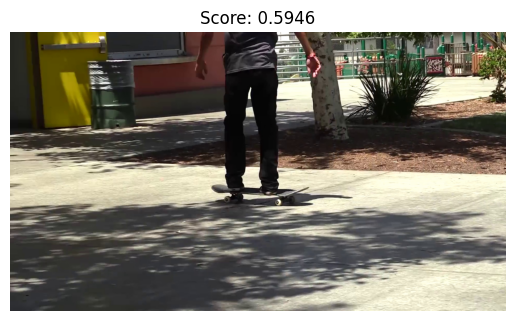

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0023.jpg', 'start_time': 46, 'end_time': 48, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

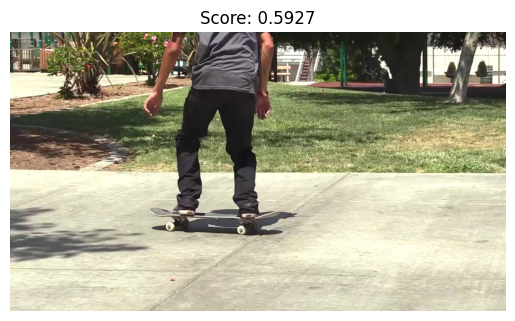

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0088.jpg', 'start_time': 176, 'end_time': 178, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.0160006

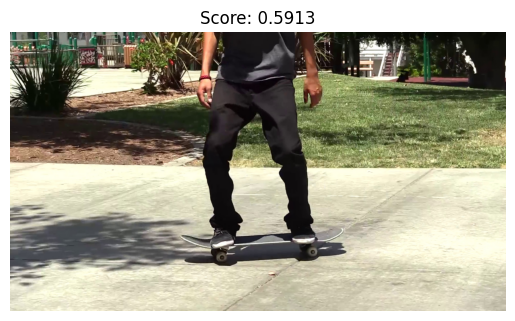

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0011.jpg', 'start_time': 22, 'end_time': 24, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

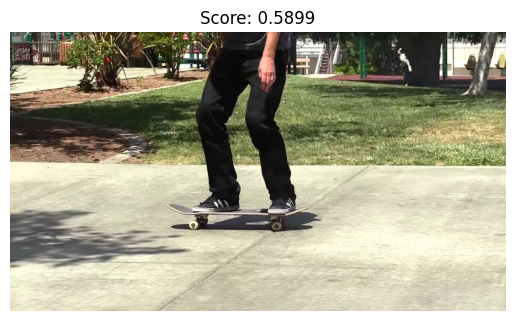

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0010.jpg', 'start_time': 20, 'end_time': 22, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

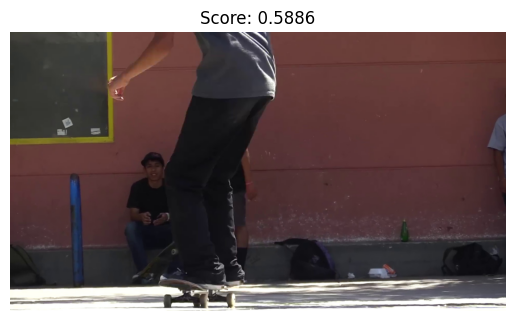

In [6]:
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt

def search_frame_by_text(text_query, top_k=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load("ViT-B/32", device=device)
    
    text_tokens = clip.tokenize([text_query]).to(device)
    
    with torch.no_grad():
        text_embedding = model.encode_text(text_tokens).cpu().numpy()[0]

    query_body = {
        "size": 5,
        "query": {
            "knn": {
                "frame_embedding": {
                    "vector": text_embedding.tolist(),
                    "k": top_k,
                }
            }
        }
    }
    
    response = client.search(index="user13", body=query_body)
    hits = response["hits"]["hits"]

    print("Top 5 results:")
    for hit in hits:
        print(f"Video ID: {hit['_source']['video_id']}, Frame File: {hit['_source']['frame_file']}, Score: {hit['_score']}")

    # Display the top K results
    for hit in response['hits']['hits']:
        print(hit['_source'])
        video_id = hit['_source']['video_id']
        frame_path = hit['_source']['frame_file'] 
        score = hit['_score']
        img = Image.open(f"keyframes/{video_id}/{frame_path}")
        plt.imshow(img)
        plt.title(f"Score: {score:.4f}")
        plt.axis('off')
        plt.show()
        
    
# Example usage
search_frame_by_text("a man skateboarding", top_k=5)
    

## Image to Text Retrieval

{'took': 5, 'timed_out': False, '_shards': {'total': 4, 'successful': 4, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 78, 'relation': 'eq'}, 'max_score': 0.5600112, 'hits': [{'_index': 'user13', '_id': '11', '_score': 0.5600112, '_source': {'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0011.jpg', 'start_time': 22, 'end_time': 24, 'captions': ['', ' A few other men are shown playing guitars as they sit.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.0106

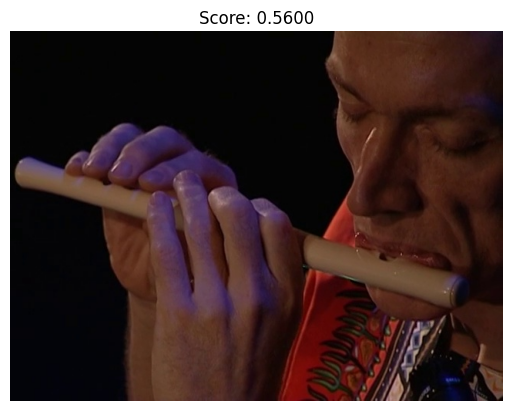

{'video_id': 'oGwn4NUeoy8', 'frame_file': 'frame_0022.jpg', 'start_time': 44, 'end_time': 46, 'captions': ['', ' A woman begins playing the drums while another plays piano and the others watch.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.004185

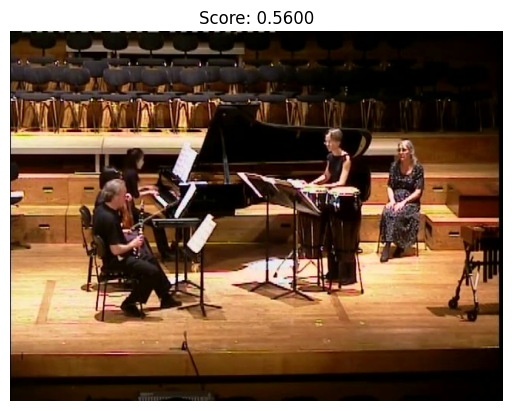

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0044.jpg', 'start_time': 88, 'end_time': 90, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

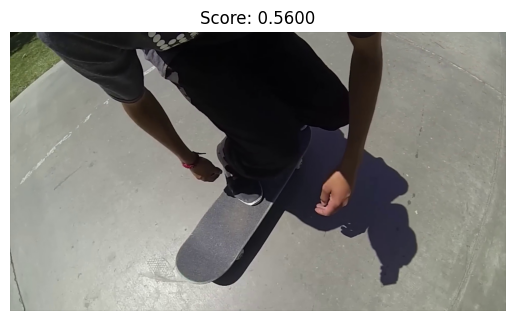

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0094.jpg', 'start_time': 188, 'end_time': 190, 'captions': [''], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.01600060798227787, 0.01088145561516285, 0.006008759140968323, 0.02

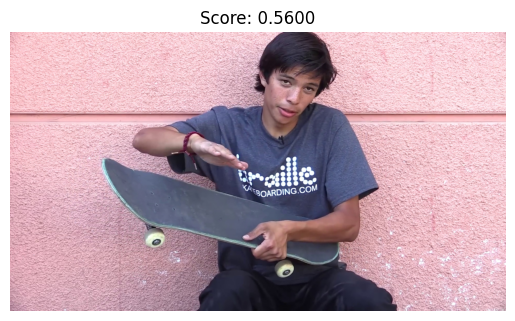

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0039.jpg', 'start_time': 78, 'end_time': 80, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

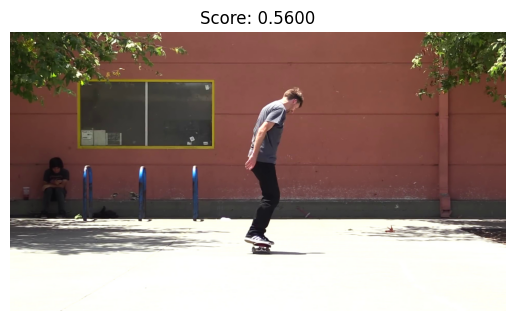

In [15]:
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def search_caption_by_image(image_path, top_k=5):
    # Embed the image passed by the user
    # With this we can search for the most similar caption to the image
    # This works because they are embedded with the same model, and therefore in the same space, which means we can compare them
    img = Image.open(image_path)
    img = preprocess(img).unsqueeze(0).to(device)
    img_embedding = model.encode_image(img).cpu().tolist()[0]

    query_body = {
        "size": 5,
        "query": {
            "knn": {
                "caption_embeddings": {
                    "vector": img_embedding,
                    "k": top_k,
                }
            }
        }
    }
    
    response = client.search(index="user13", body=query_body)
    print(response)
    hits = response["hits"]["hits"]

    print("Top 5 results:")
    for hit in hits:
        print(f"Video ID: {hit['_source']['video_id']}, Frame File: {hit['_source']['frame_file']}, Score: {hit['_score']}")
        # You can also access other fields in the hit if needed
        
    # Show the Image
    for hit in response['hits']['hits']:
        print(hit['_source'])
        video_id = hit['_source']['video_id']
        frame_path = hit['_source']['frame_file']  # or construct using video_id/timestamp
        score = hit['_score']
        img = Image.open(f"keyframes/{video_id}/{frame_path}")
        plt.imshow(img)
        plt.title(f"Score: {score:.4f}")
        plt.axis('off')
        plt.show()
        
    
# Example usage
directory = "sample_images"
img_file = "black_guy.png"
search_caption_by_image(f"{directory}/{img_file}", top_k=5)
    

## Image to Image Retrieval

{'took': 3, 'timed_out': False, '_shards': {'total': 4, 'successful': 4, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 43, 'relation': 'eq'}, 'max_score': 0.8273648, 'hits': [{'_index': 'user13', '_id': '598', '_score': 0.8273648, '_source': {'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0087.jpg', 'start_time': 174, 'end_time': 176, 'captions': [''], 'frame_embedding': [-0.004631915595382452, 0.030859995633363724, -0.0021444594021886587, 0.021468522027134895, -0.011574134230613708, 0.006702146027237177, 0.01667734794318676, 0.007506652269512415, 0.03847886621952057, 0.0072843655943870544, -0.001614233129657805, -0.028016550466418266, -0.01546176802366972, -0.003956180531531572, -0.025640005245804787, -0.002344739157706499, -0.06893753260374069, 0.005191545467823744, -0.0001354359119432047, -0.042558301240205765, 0.05331581458449364, -0.013221215456724167, 0.002345188520848751, -0.004505933728069067, -0.0026335089933127165, -0.002170414663851261, -0.00821504183113575, -0.00

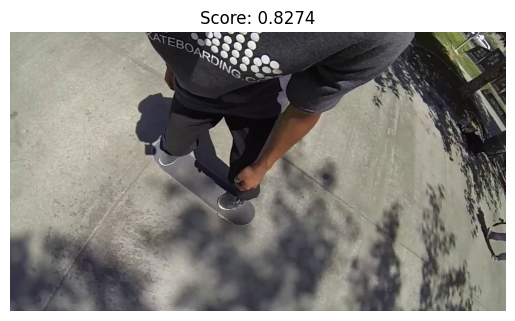

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0077.jpg', 'start_time': 154, 'end_time': 156, 'captions': [''], 'frame_embedding': [0.0026627101469784975, 0.04068330302834511, 0.02085539884865284, 0.0037221445236355066, -0.01650051213800907, 0.012819214724004269, -0.014281545765697956, -0.03430451825261116, 0.02936723455786705, -0.01413380354642868, 0.010914918966591358, -0.02151915244758129, -0.03333428502082825, -0.0074858530424535275, -0.0068663074634969234, 0.01714831404387951, -0.0908227190375328, 0.012317787855863571, -0.0034377132542431355, -0.07480228692293167, 0.015609491616487503, -0.0146462582051754, 0.012659749016165733, 0.0047682346776127815, 0.007125027943402529, -0.005500194150954485, 0.027082405984401703, -0.00280379643663764, 0.016449693590402603, -0.015708522871136665, -0.005976798944175243, -0.018098436295986176, -0.001655598171055317, -0.03427278622984886, 0.06504102051258087, 0.03363995626568794, 0.031187769025564194, 0.00663190521299839, -0.0024037782568484545, 

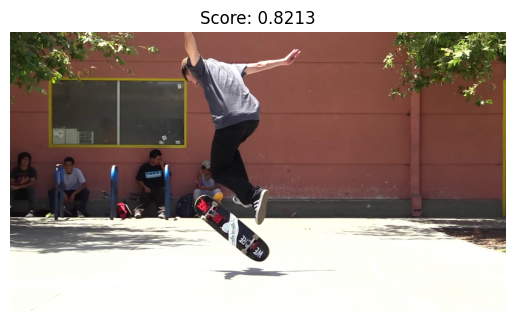

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0069.jpg', 'start_time': 138, 'end_time': 140, 'captions': [''], 'frame_embedding': [-0.0004904167726635933, 0.02601930871605873, 0.016447003930807114, 0.03515516594052315, -0.012038826011121273, 0.021045085042715073, 0.002683414379134774, -0.024191964417696, 0.0011524735018610954, 0.003910609986633062, -0.01536563690751791, -0.022435961291193962, -0.01587909273803234, 0.001832424197345972, -0.008860993199050426, -0.009354689158499241, -0.06349730491638184, -0.014046532101929188, 0.009317638352513313, -0.03947196155786514, 0.025290513411164284, -0.02016563154757023, 0.0012964450288563967, 0.03829449042677879, -0.01489287056028843, -0.006511271465569735, 0.01572561077773571, -0.012762918137013912, 0.012138045392930508, -0.0038727778010070324, -0.02446996606886387, -0.04043951258063316, 0.0026698834262788296, -0.022798720747232437, 0.03855392709374428, 0.03888733312487602, 0.007680061273276806, 0.017172368243336678, -0.02776876464486122, 0

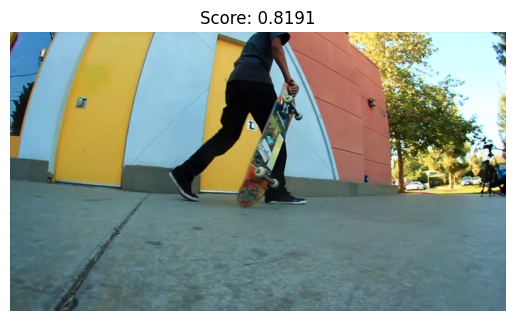

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0073.jpg', 'start_time': 146, 'end_time': 148, 'captions': [''], 'frame_embedding': [0.03447755053639412, 0.026123007759451866, 0.0013789522927254438, 0.008956740610301495, 0.011456946842372417, 0.026124130934476852, 0.009686915203928947, -0.018716298043727875, -0.01136227510869503, -0.011135358363389969, -0.03939177840948105, -0.011614233255386353, -0.006745385471731424, -0.02561534382402897, -0.03276621177792549, 0.014594950713217258, -0.0771491751074791, -0.008154966868460178, 0.008844495750963688, -0.053300827741622925, -0.037222329527139664, -0.03642818331718445, -0.009417405351996422, 0.03067704662680626, -0.01435069739818573, -0.012042976915836334, 0.02426166832447052, 0.015093263238668442, -0.0009404345764778554, -0.005642044823616743, -0.018695667386054993, -0.01626387983560562, 0.0015878372360020876, -0.04358182102441788, 0.04922586679458618, 0.040882136672735214, 0.004943347070366144, 0.026177657768130302, -0.00129177072085440

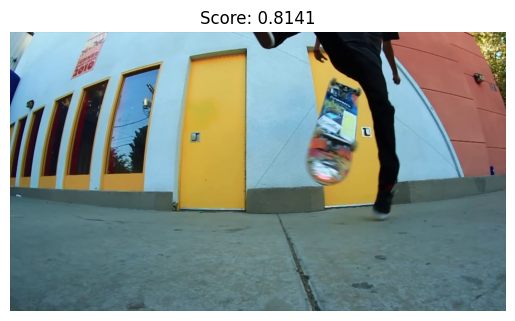

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0068.jpg', 'start_time': 136, 'end_time': 138, 'captions': [''], 'frame_embedding': [-0.0002886611910071224, 0.03230394050478935, 0.02389093115925789, 0.03264034166932106, -0.028307490050792694, 0.009591580368578434, -0.0049552107229828835, -0.03990752622485161, 0.01774456910789013, -0.015521912835538387, 0.001714474754408002, -0.026633700355887413, -0.011573930270969868, 0.02437061257660389, -0.026732170954346657, 0.006454516667872667, -0.01739802025258541, 0.00663264375180006, 0.009624590165913105, -0.046394847333431244, 0.030141513794660568, -0.03043007291853428, 0.02575371414422989, 0.00499384431168437, -0.019142260774970055, 0.010579684749245644, 0.012635240331292152, 0.0026185617316514254, 0.03685685619711876, -0.02122344821691513, -0.025628065690398216, -0.020353080704808235, -0.006320788059383631, -0.03588654473423958, 0.02053256705403328, 0.03367799147963524, 0.021645737811923027, 0.03497697412967682, 0.007633265107870102, 0.050

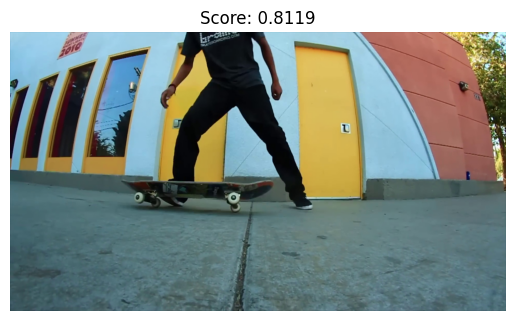

In [35]:
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def search_frame_by_image(image_path, top_k=5):
    # Embed the image passed by the user
    # With this we can search for the most similar caption to the image
    # This works because they are embedded with the same model, and therefore in the same space, which means we can compare them
    img = Image.open(image_path)
    img = preprocess(img).unsqueeze(0).to(device)
    img_embedding = model.encode_image(img).cpu().tolist()[0]

    query_body = {
        "size": 5,
        "query": {
            "knn": {
                "frame_embedding": {
                    "vector": img_embedding,
                    "k": top_k,
                }
            }
        }
    }
    
    response = client.search(index="user13", body=query_body)
    print(response)
    hits = response["hits"]["hits"]

    print("Top 5 results:")
    for hit in hits:
        print(f"Video ID: {hit['_source']['video_id']}, Frame File: {hit['_source']['frame_file']}, Score: {hit['_score']}")
        # You can also access other fields in the hit if needed
        
    # Show the Image
    for hit in response['hits']['hits']:
        print(hit['_source'])
        video_id = hit['_source']['video_id']
        frame_path = hit['_source']['frame_file']  # or construct using video_id/timestamp
        score = hit['_score']
        img = Image.open(f"keyframes/{video_id}/{frame_path}")
        plt.imshow(img)
        plt.title(f"Score: {score:.4f}")
        plt.axis('off')
        plt.show()
        
    
# Example usage
directory = "sample_images"
img_file = "skateboarding_2.png"
search_frame_by_image(f"{directory}/{img_file}", top_k=5)
    

## Combination Embeddings
e.g: images + images and text + images

Top 5 results:
Video ID: o1WPnnvs00I, Frame File: frame_0100.jpg, Score: 0.7339575
Video ID: o1WPnnvs00I, Frame File: frame_0102.jpg, Score: 0.72469723
Video ID: o1WPnnvs00I, Frame File: frame_0084.jpg, Score: 0.7162534
Video ID: o1WPnnvs00I, Frame File: frame_0074.jpg, Score: 0.71202123
Video ID: o1WPnnvs00I, Frame File: frame_0104.jpg, Score: 0.7105175
{'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0100.jpg', 'start_time': 200, 'end_time': 202, 'captions': ['', ' One man is playing drums while the others are on flute and guitar.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, 

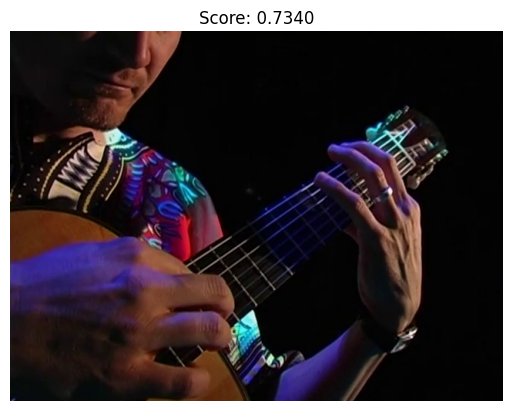

{'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0102.jpg', 'start_time': 204, 'end_time': 206, 'captions': ['', ' One man is playing drums while the others are on flute and guitar.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.004185630008578300

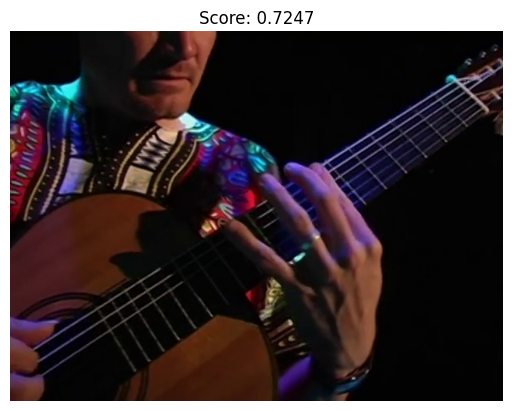

{'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0084.jpg', 'start_time': 168, 'end_time': 170, 'captions': [''], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.01600060798227787, 0.01088145561516285, 0.006008759140968323, 0.02

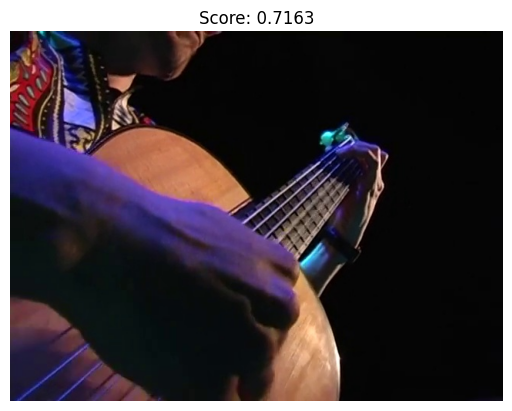

{'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0074.jpg', 'start_time': 148, 'end_time': 150, 'captions': ['', ' The group plays for the audience, occasionally zooming in on individuals.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.00418563000

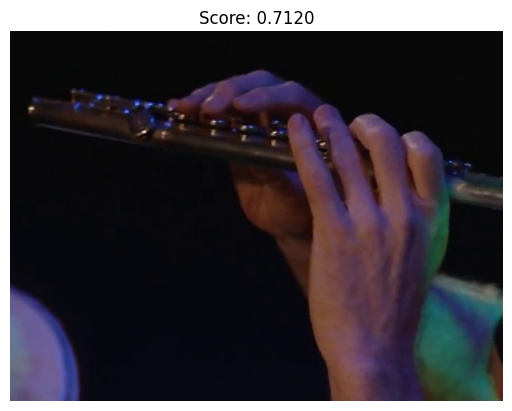

{'video_id': 'o1WPnnvs00I', 'frame_file': 'frame_0104.jpg', 'start_time': 208, 'end_time': 210, 'captions': ['', ' One man is playing drums while the others are on flute and guitar.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.004185630008578300

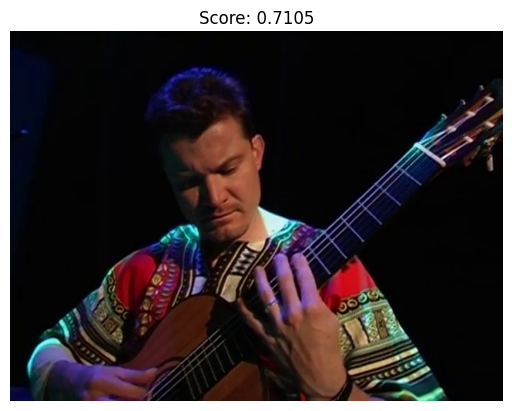

In [5]:
# Combined Text + Image Query
import clip
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 1. Encode text query
text_query = "a man playing guitar"
text_tokens = clip.tokenize([text_query]).to(device)
with torch.no_grad():
    text_embedding = model.encode_text(text_tokens).cpu().numpy()[0]

# 2. Encode image query
from PIL import Image
image_path = "sample_images/man_playing_guitar.png"
image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)
with torch.no_grad():
    image_embedding = model.encode_image(image).cpu().numpy()[0]

# 3. Combine both embeddings
alpha = 0.5  # adjust this weight if needed
combined_embedding = alpha * text_embedding + (1 - alpha) * image_embedding

# 4. Search OpenSearch
query_body = {
    "size": 5,
    "query": {
        "knn": {
            "frame_embedding": {
                "vector": combined_embedding.tolist(),
                "k": 5
            }
        }
    }
}

response = client.search(index="user13", body=query_body)
hits = response["hits"]["hits"]

print("Top 5 results:")
for hit in hits:
    print(f"Video ID: {hit['_source']['video_id']}, Frame File: {hit['_source']['frame_file']}, Score: {hit['_score']}")
    # You can also access other fields in the hit if needed
        
# Show the Image
for hit in response['hits']['hits']:
    print(hit['_source'])
    video_id = hit['_source']['video_id']
    frame_path = hit['_source']['frame_file']  # or construct using video_id/timestamp
    score = hit['_score']
    img = Image.open(f"keyframes/{video_id}/{frame_path}")
    plt.imshow(img)
    plt.title(f"Score: {score:.4f}")
    plt.axis('off')
    plt.show()

# Section 3.2 Large Vison and Language Models


## Creating the model and asking to describe an image

In [40]:
from ollama import Client
from PIL import Image

client = Client(
  host='https://twiz.novasearch.org/ollama',
  headers={'x-some-header': 'some-value'}
)

model_multimodal = 'llava-phi3:latest'


img = './china.jpg'
image = Image.open(img)
#image.show()

response = client.chat(model=model_multimodal, messages=[
  {
    'role': 'user',
    'content': 'Describe this image.',
    'images': [img]
  },
])

print(response.message.content)

This is a vibrant and bustling scene set in an urban environment. The focal point of the image is a large screen mounted on a gray concrete wall, displaying a video of a man speaking to an audience. His presence is marked by his suit and tie, suggesting he might be delivering an important speech or presentation.

The crowd gathered around the screen appears to be engaged and attentive, indicating that this event holds significance for them. The majority of the attendees are dressed in yellow shirts, adding a splash of color to the scene. Interestingly, one individual stands out from the rest due to their red shirt.

The backdrop features tall buildings under an overcast sky, hinting at the location being within a city or metropolitan area. The overall atmosphere suggests it might be a public event or gathering related to technology or communication, given the presence of the screen and audience.

Please note that this description is based on the visible elements in the image and does n

Retrieval Augmented VQA: For visual questions, use your CLIP-based index to retrieve 
candidate frames and select the top retrieved frame. This image frame and the visual 
question must then be passed to Llava to obtain the answer. 

Top 5 results:
Video ID: t6f_O8a4sSg, Frame File: frame_0049.jpg, Score: 0.58709604
Video ID: t6f_O8a4sSg, Frame File: frame_0090.jpg, Score: 0.58661735
Video ID: t6f_O8a4sSg, Frame File: frame_0023.jpg, Score: 0.5854585
Video ID: t6f_O8a4sSg, Frame File: frame_0050.jpg, Score: 0.58529496
Video ID: t6f_O8a4sSg, Frame File: frame_0012.jpg, Score: 0.58482534
{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0049.jpg', 'start_time': 98, 'end_time': 100, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.02641258

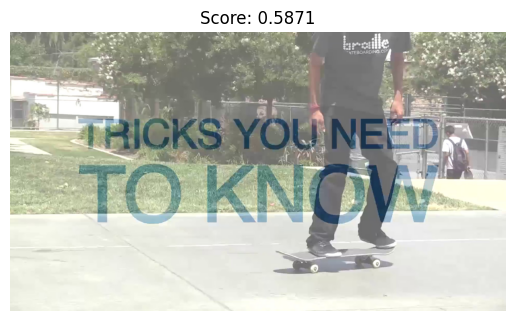

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0090.jpg', 'start_time': 180, 'end_time': 182, 'captions': ['', ' The skateboarder rubs the top of his grip tape with his hand.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.

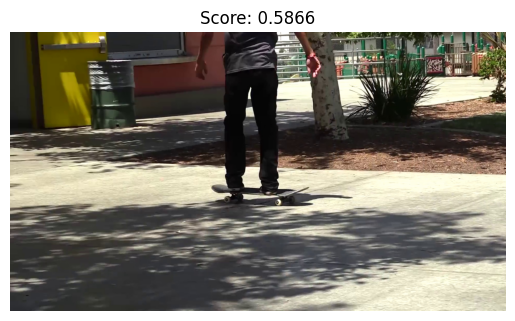

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0023.jpg', 'start_time': 46, 'end_time': 48, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

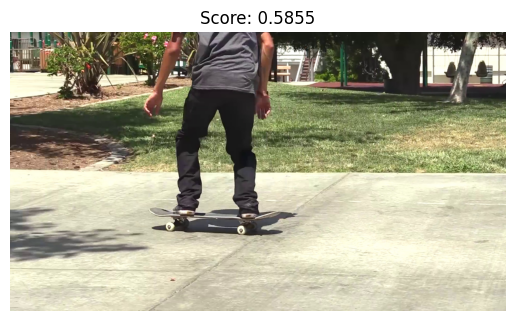

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0050.jpg', 'start_time': 100, 'end_time': 102, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.0160006

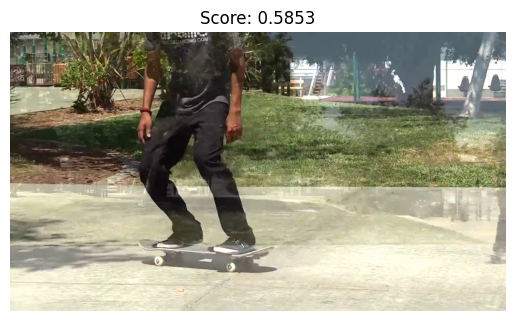

{'video_id': 't6f_O8a4sSg', 'frame_file': 'frame_0012.jpg', 'start_time': 24, 'end_time': 26, 'captions': ['', 'Skateboarder to different tricks spinning their boards.'], 'label': '', 'label_embeddings': [0.007799881976097822, 0.018882861360907555, 0.009807411581277847, 0.01005800161510706, -0.005760127678513527, -0.004084109328687191, -0.011560827493667603, -0.03606748208403587, 0.005052180960774422, 0.02969602309167385, -0.004681052174419165, -0.009320195764303207, -0.0006607387331314385, -0.02510167844593525, 0.023727083578705788, 0.007500703912228346, 0.041294824331998825, 0.010667148046195507, -0.015971357002854347, -0.026412583887577057, 0.022407492622733116, 0.022607071325182915, 0.012260215356945992, -0.0011765705421566963, -0.010670523159205914, 0.015397845767438412, 0.004026798531413078, 0.00765460217371583, 0.01705959066748619, 0.004234327003359795, -0.011457892134785652, -0.009408154524862766, -0.003794998861849308, -0.010924546979367733, -0.0041856300085783005, 0.016000607

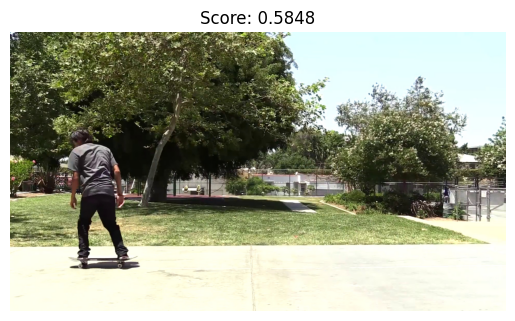

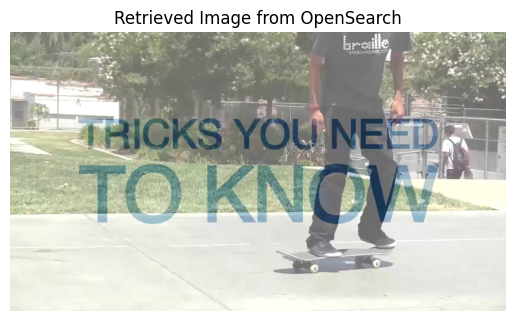

1. Skateboarding on a street or sidewalk, likely in an urban setting.
2. Posing for the camera while standing on their skateboard.
3. Reading and learning more about how to skateboard by observing someone else's actions or techniques.


In [8]:
from ollama import Client
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def retrievel_augmented_vqa(question_query):
    text_tokens = clip.tokenize([question_query]).to(device)
    
    with torch.no_grad():
        text_embedding = model.encode_text(text_tokens).cpu().numpy()[0]
        
    query_body = {
        "size": 5,
        "query": {
            "knn": {
                "frame_embedding": {
                    "vector": text_embedding.tolist(),
                    "k": 5,
                }
            }
        }
    }
    
    response = client.search(index="user13", body=query_body)
    hits = response["hits"]["hits"]

    print("Top 5 results:")
    for hit in hits:
        print(f"Video ID: {hit['_source']['video_id']}, Frame File: {hit['_source']['frame_file']}, Score: {hit['_score']}")
        
            
    # Show the top K results
    for hit in response['hits']['hits']:
        print(hit['_source'])
        video_id = hit['_source']['video_id']
        frame_path = hit['_source']['frame_file']  # or construct using video_id/timestamp
        score = hit['_score']
        img = Image.open(f"keyframes/{video_id}/{frame_path}")
        plt.imshow(img)
        plt.title(f"Score: {score:.4f}")
        plt.axis('off')
        plt.show()
    
    # Now we select the first image from the top K results
    # and use it to ask the multimodal model a question
    top_hit = hits[0]
    video_id = top_hit['_source']['video_id']
    frame_path = top_hit['_source']['frame_file']  # or construct using video_id/timestamp
    img = Image.open(f"keyframes/{video_id}/{frame_path}")
    plt.imshow(img)
    plt.title(f"Retrieved Image from OpenSearch")
    plt.axis('off')
    plt.show()
    
    llava_client= Client(
        host='https://twiz.novasearch.org/ollama',
        headers={'x-some-header': 'some-value'}
    )
    model_multimodal = 'llava-phi3:latest'

    response = llava_client.chat(model=model_multimodal, messages=[
    {
        'role': 'user',
        'content': question_query,
        'images': [f"keyframes/{video_id}/{frame_path}"]
    },
    ])
    
    print(response.message.content)

# Example usage
question = "What is the skateboarder doing?"
retrievel_augmented_vqa(question)